# Phase 4: Model Training & Evaluation

## Overview
This notebook trains machine learning models to detect NTFS timestomping based on file-level features from Phase 3.

## Models
1. Random Forest
2. XGBoost
3. LightGBM
4. Logistic Regression

## Workflow
1. Load training features from Phase 3
2. Prepare labels (from detection flags)
3. Handle class imbalance (SMOTE, class weights)
4. Train-test split (80/20 stratified)
5. Train all 4 models
6. Evaluate on test set
7. Validate on held-out validation datasets (5 datasets)

## Metrics
- Accuracy, Precision, Recall, F1-Score
- Confusion Matrix (TP, FP, TN, FN)
- ROC-AUC Score
- Classification Report

## Input
- `file_features_training.csv` - Training features (22 datasets)
- `detection_flags_training.csv` - Training labels

## Validation Datasets
- 02-APT19, 09-APT40, 12-Kimsuky, 13-Winnti731, LoneWolf


In [1]:
# [Cell 2] Imports and Configuration

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Joblib for model saving
import joblib

# =============================================================================
# DIRECTORY CONFIGURATION
# =============================================================================

PHASE3_DIR = Path("/Users/soni/Github/Digital-Detectives_Thesis/data/Phase 3: Feature Engineering & Labeling")
OUTPUT_DIR = Path("/Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Validation datasets
VALIDATION_DATASETS = ["02-APT19", "09-APT40", "12-Kimsuky", "13-Winnti731", "LoneWolf"]

print("Libraries imported successfully.")
print(f"\nPhase 3 input: {PHASE3_DIR}")
print(f"Phase 4 output: {OUTPUT_DIR}")


Libraries imported successfully.

Phase 3 input: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 3: Feature Engineering & Labeling
Phase 4 output: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training


## Step 1: Load Training Data

Load the merged training features and detection flags from Phase 3.


In [2]:
# [Cell 4] Load Training Data

print("Loading training data from Phase 3...")

# Load features
features_path = PHASE3_DIR / "file_features_training.csv"
df_features = pd.read_csv(features_path, low_memory=False)
print(f"Features loaded: {len(df_features):,} files")

# Load detection flags (contains labels)
flags_path = PHASE3_DIR / "detection_flags_training.csv"
df_flags = pd.read_csv(flags_path, low_memory=False)
print(f"Flags loaded: {len(df_flags):,} files")

# Verify alignment
assert len(df_features) == len(df_flags), "Feature and flag counts do not match!"
print(f"\nDatasets included: {df_features['dataID'].nunique()}")
print(f"Dataset distribution:")
print(df_features['dataID'].value_counts())


Loading training data from Phase 3...
Features loaded: 953,366 files
Flags loaded: 953,366 files

Datasets included: 21
Dataset distribution:
dataID
09-PE              111889
10-PE              110574
08-PE              110541
07-PE              110336
03-PE              109985
02-PE              105251
01-PE               37375
01-APT17            31455
05-APT29            29860
07-APT37            29426
04-APT28            29399
03-APT21            28028
06-APT30            22266
08-APT38            20478
10-DarkHotel663     10625
11-DarkHotelbbd     10536
05-PE                9451
06-PE                9434
11-PE                9415
12-PE                9160
04-PE                7882
Name: count, dtype: int64


In [3]:
# [Cell 5] Define Target Label

# Use flag_potential_timestomp as the primary target
# This flag indicates: timestamp changes AND (backward jump OR zero nanoseconds)

TARGET_COLUMN = 'flag_potential_timestomp'

# Create target variable
y = df_flags[TARGET_COLUMN].astype(int)

print(f"Target column: {TARGET_COLUMN}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nClass balance:")
print(f"  Negative (0): {(y == 0).sum():,} ({(y == 0).mean() * 100:.2f}%)")
print(f"  Positive (1): {(y == 1).sum():,} ({(y == 1).mean() * 100:.2f}%)")

# Calculate imbalance ratio
imbalance_ratio = (y == 0).sum() / (y == 1).sum() if (y == 1).sum() > 0 else float('inf')
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")


Target column: flag_potential_timestomp

Class distribution:
flag_potential_timestomp
0    949622
1      3744
Name: count, dtype: int64

Class balance:
  Negative (0): 949,622 (99.61%)
  Positive (1): 3,744 (0.39%)

Imbalance ratio: 253.64:1


In [4]:
# [Cell 6] Select Features for Training

# Define feature columns (exclude identifiers and metadata)
EXCLUDE_COLUMNS = [
    'FileFRN', 'dataID', 'FileName', 'FilePath',
    # Exclude flag columns (these are derived, not features)
    'flag_backward_timestamp', 'flag_creation_changed', 'flag_zero_nanoseconds',
    'flag_logfile_usn_mismatch', 'flag_usn_basic_pattern', 'flag_repeated_si_update',
    'flag_only_si_modified', 'flag_potential_timestomp', 'flag_silent_timestomp',
    'flag_high_suspicion', 'suspicion_score'
]

# Get feature columns
feature_columns = [col for col in df_features.columns if col not in EXCLUDE_COLUMNS]

# Create feature matrix
X = df_features[feature_columns].copy()

# Handle any remaining NaN values
X = X.fillna(0)

# Convert boolean columns to int
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {len(feature_columns)}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")


Feature matrix shape: (953366, 29)
Number of features: 29

Feature columns:
   1. num_timestamp_changes
   2. num_backward_jumps
   3. num_forward_jumps
   4. num_creation_changes
   5. max_backward_jump_seconds
   6. mean_jump_seconds
   7. timestamp_change_density
   8. num_zero_nanosecond_events
   9. only_SI_modified
  10. num_update_resident_value
  11. repeated_update_resident_value
  12. consecutive_timestamp_changes
  13. num_logfile_events
  14. has_logfile_ts_change
  15. has_usn_basic_info
  16. has_usn_close
  17. has_usn_file_create
  18. num_usn_basic_info
  19. num_usn_close
  20. num_usn_file_create
  21. logfile_usn_mismatch
  22. has_usn_basic_pattern
  23. num_usnjrnl_events
  24. min_inter_event_delta
  25. max_inter_event_delta
  26. mean_inter_event_delta
  27. burstiness_score
  28. event_time_span_seconds
  29. total_events


## Step 2: Train-Test Split

Split data into training (80%) and test (20%) sets using stratified sampling to preserve class distribution.


In [5]:
# [Cell 8] Train-Test Split

# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test Split Complete")
print(f"\nTraining set: {len(X_train):,} samples")
print(f"  Class 0: {(y_train == 0).sum():,} ({(y_train == 0).mean() * 100:.2f}%)")
print(f"  Class 1: {(y_train == 1).sum():,} ({(y_train == 1).mean() * 100:.2f}%)")

print(f"\nTest set: {len(X_test):,} samples")
print(f"  Class 0: {(y_test == 0).sum():,} ({(y_test == 0).mean() * 100:.2f}%)")
print(f"  Class 1: {(y_test == 1).sum():,} ({(y_test == 1).mean() * 100:.2f}%)")


Train-Test Split Complete

Training set: 762,692 samples
  Class 0: 759,697 (99.61%)
  Class 1: 2,995 (0.39%)

Test set: 190,674 samples
  Class 0: 189,925 (99.61%)
  Class 1: 749 (0.39%)


In [6]:
# [Cell 9] Handle Class Imbalance with SMOTE

print("Applying SMOTE to handle class imbalance...")

# Apply SMOTE only to training data
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE:")
print(f"  Training samples: {len(X_train):,}")
print(f"  Class 0: {(y_train == 0).sum():,}")
print(f"  Class 1: {(y_train == 1).sum():,}")

print(f"\nAfter SMOTE:")
print(f"  Training samples: {len(X_train_balanced):,}")
print(f"  Class 0: {(y_train_balanced == 0).sum():,}")
print(f"  Class 1: {(y_train_balanced == 1).sum():,}")

# Also prepare version with class weights (for algorithms that support it)
# Calculate class weights
class_weight_dict = {
    0: 1.0,
    1: imbalance_ratio
}
print(f"\nClass weights for weighted training: {class_weight_dict}")


Applying SMOTE to handle class imbalance...

Before SMOTE:
  Training samples: 762,692
  Class 0: 759,697
  Class 1: 2,995

After SMOTE:
  Training samples: 1,519,394
  Class 0: 759,697
  Class 1: 759,697

Class weights for weighted training: {0: 1.0, 1: np.float64(253.6383547008547)}


In [7]:
# [Cell 10] Feature Scaling

# Scale features for algorithms that benefit from it (Logistic Regression)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# Keep original for tree-based models (they don't need scaling)
X_train_trees = X_train_balanced.values
X_test_trees = X_test.values

print("Feature scaling complete.")
print(f"Scaled training shape: {X_train_scaled.shape}")
print(f"Scaled test shape: {X_test_scaled.shape}")

# Save scaler for later use
scaler_path = OUTPUT_DIR / "feature_scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"\nScaler saved to: {scaler_path}")


Feature scaling complete.
Scaled training shape: (1519394, 29)
Scaled test shape: (190674, 29)

Scaler saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/feature_scaler.joblib


## Step 3: Model Training

Train all 4 models on the balanced training data.

### Models:
1. **Random Forest**: Ensemble of decision trees, robust to overfitting
2. **XGBoost**: Gradient boosting with regularization
3. **LightGBM**: Fast gradient boosting, handles imbalance well
4. **Logistic Regression**: Baseline linear model with L2 regularization


In [8]:
# [Cell 12] Evaluation Helper Functions

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained model and return metrics.
    """
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Metrics
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    }
    
    return metrics, y_pred, y_prob


def print_evaluation(metrics):
    """
    Print evaluation metrics in formatted output.
    """
    print(f"\n{'='*50}")
    print(f"Model: {metrics['Model']}")
    print(f"{'='*50}")
    print(f"Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall:    {metrics['Recall']:.4f}")
    print(f"F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"ROC-AUC:   {metrics['ROC-AUC']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {metrics['TP']:,}  |  FP: {metrics['FP']:,}")
    print(f"  FN: {metrics['FN']:,}  |  TN: {metrics['TN']:,}")


print("Evaluation helper functions defined.")


Evaluation helper functions defined.


In [9]:
# [Cell 13] Train Random Forest

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # Handle imbalance
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train_trees, y_train_balanced)

# Evaluate
rf_metrics, rf_pred, rf_prob = evaluate_model(rf_model, X_test_trees, y_test, "Random Forest")
print_evaluation(rf_metrics)

# Save model
rf_path = OUTPUT_DIR / "model_random_forest.joblib"
joblib.dump(rf_model, rf_path)
print(f"\nModel saved to: {rf_path}")


Training Random Forest...

Model: Random Forest
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Confusion Matrix:
  TP: 749  |  FP: 0
  FN: 0  |  TN: 189,925

Model saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_random_forest.joblib


In [10]:
# [Cell 14] Train XGBoost

print("Training XGBoost...")

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train_balanced == 0).sum() / (y_train_balanced == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_train_trees, y_train_balanced)

# Evaluate
xgb_metrics, xgb_pred, xgb_prob = evaluate_model(xgb_model, X_test_trees, y_test, "XGBoost")
print_evaluation(xgb_metrics)

# Save model
xgb_path = OUTPUT_DIR / "model_xgboost.joblib"
joblib.dump(xgb_model, xgb_path)
print(f"\nModel saved to: {xgb_path}")


Training XGBoost...

Model: XGBoost
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Confusion Matrix:
  TP: 749  |  FP: 0
  FN: 0  |  TN: 189,925

Model saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_xgboost.joblib


In [11]:
# [Cell 15] Train LightGBM

print("Training LightGBM...")

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train_trees, y_train_balanced)

# Evaluate
lgbm_metrics, lgbm_pred, lgbm_prob = evaluate_model(lgbm_model, X_test_trees, y_test, "LightGBM")
print_evaluation(lgbm_metrics)

# Save model
lgbm_path = OUTPUT_DIR / "model_lightgbm.joblib"
joblib.dump(lgbm_model, lgbm_path)
print(f"\nModel saved to: {lgbm_path}")


Training LightGBM...

Model: LightGBM
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Confusion Matrix:
  TP: 749  |  FP: 0
  FN: 0  |  TN: 189,925

Model saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_lightgbm.joblib


In [12]:
# [Cell 16] Train Logistic Regression

print("Training Logistic Regression...")

lr_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    n_jobs=-1
)

# Use scaled features for Logistic Regression
lr_model.fit(X_train_scaled, y_train_balanced)

# Evaluate
lr_metrics, lr_pred, lr_prob = evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")
print_evaluation(lr_metrics)

# Save model
lr_path = OUTPUT_DIR / "model_logistic_regression.joblib"
joblib.dump(lr_model, lr_path)
print(f"\nModel saved to: {lr_path}")


Training Logistic Regression...

Model: Logistic Regression
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Confusion Matrix:
  TP: 749  |  FP: 0
  FN: 0  |  TN: 189,925

Model saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_logistic_regression.joblib


## Step 4: Model Comparison

Compare all trained models side by side.


In [13]:
# [Cell 18] Model Comparison Summary

# Collect all metrics
all_metrics = [rf_metrics, xgb_metrics, lgbm_metrics, lr_metrics]
df_comparison = pd.DataFrame(all_metrics)

# Display comparison table
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

# Format for display
display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
print(f"\n{df_comparison[display_cols].to_string(index=False)}")

# Confusion matrix summary
print(f"\n{'Model':<25} {'TP':>8} {'FP':>8} {'TN':>8} {'FN':>8}")
print("-" * 60)
for m in all_metrics:
    print(f"{m['Model']:<25} {m['TP']:>8,} {m['FP']:>8,} {m['TN']:>8,} {m['FN']:>8,}")

# Find best model by F1-Score
best_model_idx = df_comparison['F1-Score'].idxmax()
best_model = df_comparison.loc[best_model_idx, 'Model']
best_f1 = df_comparison.loc[best_model_idx, 'F1-Score']

print(f"\nBest Model (by F1-Score): {best_model} ({best_f1:.4f})")

# Save comparison
comparison_path = OUTPUT_DIR / "model_comparison.csv"
df_comparison.to_csv(comparison_path, index=False)
print(f"\nComparison saved to: {comparison_path}")


MODEL COMPARISON SUMMARY

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest       1.0        1.0     1.0       1.0      1.0
            XGBoost       1.0        1.0     1.0       1.0      1.0
           LightGBM       1.0        1.0     1.0       1.0      1.0
Logistic Regression       1.0        1.0     1.0       1.0      1.0

Model                           TP       FP       TN       FN
------------------------------------------------------------
Random Forest                  749        0  189,925        0
XGBoost                        749        0  189,925        0
LightGBM                       749        0  189,925        0
Logistic Regression            749        0  189,925        0

Best Model (by F1-Score): Random Forest (1.0000)

Comparison saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_comparison.csv


In [14]:
# [Cell 19] Feature Importance Analysis

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Features (Random Forest):")
print(rf_importance.head(15).to_string(index=False))

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Features (XGBoost):")
print(xgb_importance.head(15).to_string(index=False))

# LightGBM feature importance
lgbm_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Features (LightGBM):")
print(lgbm_importance.head(15).to_string(index=False))

# Save feature importance
importance_path = OUTPUT_DIR / "feature_importance.csv"
rf_importance.to_csv(importance_path, index=False)
print(f"\nFeature importance saved to: {importance_path}")


FEATURE IMPORTANCE ANALYSIS

Top 15 Features (Random Forest):
                       Feature  Importance
     max_backward_jump_seconds    0.162478
            num_backward_jumps    0.153031
             mean_jump_seconds    0.145737
     num_update_resident_value    0.123636
            num_logfile_events    0.087181
                  total_events    0.058303
           has_usn_file_create    0.054360
           num_usn_file_create    0.050422
            num_usnjrnl_events    0.049418
         max_inter_event_delta    0.035672
repeated_update_resident_value    0.028159
       event_time_span_seconds    0.021489
        mean_inter_event_delta    0.008201
      timestamp_change_density    0.007242
         num_timestamp_changes    0.004856

Top 15 Features (XGBoost):
                      Feature  Importance
           num_backward_jumps    0.629953
    max_backward_jump_seconds    0.364768
   num_zero_nanosecond_events    0.001631
consecutive_timestamp_changes    0.000786
            

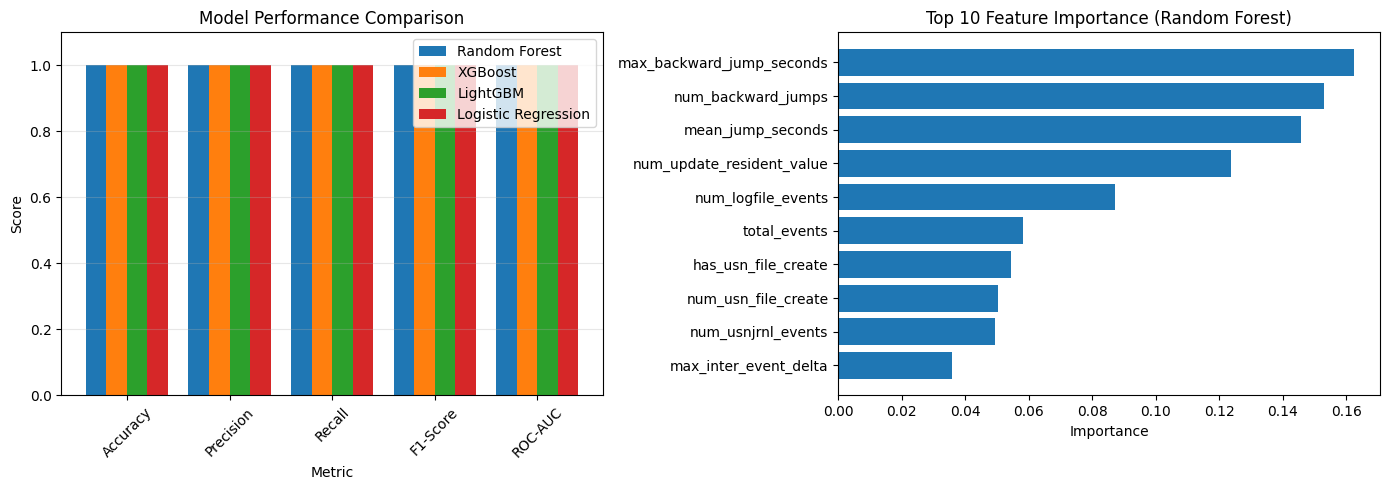


Plot saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_comparison_plot.png


In [15]:
# [Cell 20] Visualization - Model Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.2

for i, model in enumerate(all_metrics):
    values = [model[m] for m in metrics_to_plot]
    axes[0].bar(x + i * width, values, width, label=model['Model'])

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_to_plot, rotation=45)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Feature importance (top 10 from Random Forest)
top_features = rf_importance.head(10)
axes[1].barh(top_features['Feature'], top_features['Importance'])
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 10 Feature Importance (Random Forest)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {OUTPUT_DIR / 'model_comparison_plot.png'}")


## Step 5: Validation on Held-Out Datasets

Test trained models on the 5 validation datasets that were never seen during training:
1. 02-APT19
2. 09-APT40
3. 12-Kimsuky
4. 13-Winnti731
5. LoneWolf

This validates the models' ability to generalize to new data.


In [16]:
# [Cell 22] Validation Function

def validate_on_dataset(dataset_name, models_dict, feature_columns, scaler):
    """
    Validate all models on a single validation dataset.
    
    Parameters:
        dataset_name: Name of the validation dataset
        models_dict: Dictionary of trained models
        feature_columns: List of feature column names
        scaler: Fitted StandardScaler for Logistic Regression
    
    Returns:
        DataFrame with validation results
    """
    print(f"\n{'='*60}")
    print(f"VALIDATING ON: {dataset_name}")
    print(f"{'='*60}")
    
    # Load validation data
    features_path = PHASE3_DIR / f"file_features_{dataset_name}.csv"
    flags_path = PHASE3_DIR / f"detection_flags_{dataset_name}.csv"
    
    if not features_path.exists() or not flags_path.exists():
        print(f"  ERROR: Validation files not found for {dataset_name}")
        return None
    
    df_val_features = pd.read_csv(features_path, low_memory=False)
    df_val_flags = pd.read_csv(flags_path, low_memory=False)
    
    print(f"  Total files: {len(df_val_features):,}")
    
    # Prepare features
    X_val = df_val_features[feature_columns].copy()
    X_val = X_val.fillna(0)
    bool_cols = X_val.select_dtypes(include=['bool']).columns
    X_val[bool_cols] = X_val[bool_cols].astype(int)
    
    # Prepare labels
    y_val = df_val_flags[TARGET_COLUMN].astype(int)
    
    print(f"  Class 0 (Normal): {(y_val == 0).sum():,}")
    print(f"  Class 1 (Suspicious): {(y_val == 1).sum():,}")
    
    # Prepare scaled version for Logistic Regression
    X_val_scaled = scaler.transform(X_val)
    X_val_trees = X_val.values
    
    # Evaluate each model
    results = []
    for model_name, model in models_dict.items():
        # Use appropriate features
        if model_name == "Logistic Regression":
            X_eval = X_val_scaled
        else:
            X_eval = X_val_trees
        
        # Predictions
        y_pred = model.predict(X_eval)
        y_prob = model.predict_proba(X_eval)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
        
        result = {
            'Dataset': dataset_name,
            'Model': model_name,
            'Total_Files': len(y_val),
            'Actual_Positive': (y_val == 1).sum(),
            'Actual_Negative': (y_val == 0).sum(),
            'Accuracy': accuracy_score(y_val, y_pred),
            'Precision': precision_score(y_val, y_pred, zero_division=0),
            'Recall': recall_score(y_val, y_pred, zero_division=0),
            'F1-Score': f1_score(y_val, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_val, y_prob) if y_prob is not None and len(np.unique(y_val)) > 1 else np.nan,
            'TP': tp,
            'FP': fp,
            'TN': tn,
            'FN': fn
        }
        results.append(result)
        
        print(f"\n  {model_name}:")
        print(f"    Accuracy: {result['Accuracy']:.4f}, Precision: {result['Precision']:.4f}, Recall: {result['Recall']:.4f}, F1: {result['F1-Score']:.4f}")
        print(f"    TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
    
    return pd.DataFrame(results)


print("Validation function defined.")


Validation function defined.


In [17]:
# [Cell 23] Prepare Models Dictionary

models_dict = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "Logistic Regression": lr_model
}

print("Models dictionary prepared.")
print(f"Models: {list(models_dict.keys())}")


Models dictionary prepared.
Models: ['Random Forest', 'XGBoost', 'LightGBM', 'Logistic Regression']


In [18]:
# [Cell 24] Validate on 02-APT19
results_02APT19 = validate_on_dataset("02-APT19", models_dict, feature_columns, scaler)



VALIDATING ON: 02-APT19
  Total files: 21,336
  Class 0 (Normal): 21,200
  Class 1 (Suspicious): 136

  Random Forest:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 136, FP: 0, TN: 21200, FN: 0

  XGBoost:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 136, FP: 0, TN: 21200, FN: 0

  LightGBM:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 136, FP: 0, TN: 21200, FN: 0

  Logistic Regression:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 136, FP: 0, TN: 21200, FN: 0


In [19]:
# [Cell 25] Validate on 09-APT40
results_09APT40 = validate_on_dataset("09-APT40", models_dict, feature_columns, scaler)



VALIDATING ON: 09-APT40
  Total files: 21,672
  Class 0 (Normal): 21,546
  Class 1 (Suspicious): 126

  Random Forest:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 126, FP: 0, TN: 21546, FN: 0

  XGBoost:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 126, FP: 0, TN: 21546, FN: 0

  LightGBM:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 126, FP: 0, TN: 21546, FN: 0

  Logistic Regression:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 126, FP: 0, TN: 21546, FN: 0


In [20]:
# [Cell 26] Validate on 12-Kimsuky
results_12Kimsuky = validate_on_dataset("12-Kimsuky", models_dict, feature_columns, scaler)



VALIDATING ON: 12-Kimsuky
  Total files: 14,869
  Class 0 (Normal): 14,796
  Class 1 (Suspicious): 73

  Random Forest:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 73, FP: 0, TN: 14796, FN: 0

  XGBoost:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 73, FP: 0, TN: 14796, FN: 0

  LightGBM:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 73, FP: 0, TN: 14796, FN: 0

  Logistic Regression:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 73, FP: 0, TN: 14796, FN: 0


In [21]:
# [Cell 27] Validate on 13-Winnti731
results_13Winnti731 = validate_on_dataset("13-Winnti731", models_dict, feature_columns, scaler)



VALIDATING ON: 13-Winnti731
  Total files: 16,741
  Class 0 (Normal): 16,670
  Class 1 (Suspicious): 71

  Random Forest:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 71, FP: 0, TN: 16670, FN: 0

  XGBoost:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 71, FP: 0, TN: 16670, FN: 0

  LightGBM:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 71, FP: 0, TN: 16670, FN: 0

  Logistic Regression:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 71, FP: 0, TN: 16670, FN: 0


In [22]:
# [Cell 28] Validate on LoneWolf
results_LoneWolf = validate_on_dataset("LoneWolf", models_dict, feature_columns, scaler)



VALIDATING ON: LoneWolf
  Total files: 17,897
  Class 0 (Normal): 17,584
  Class 1 (Suspicious): 313

  Random Forest:
    Accuracy: 0.9998, Precision: 1.0000, Recall: 0.9872, F1: 0.9936
    TP: 309, FP: 0, TN: 17584, FN: 4

  XGBoost:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 313, FP: 0, TN: 17584, FN: 0

  LightGBM:
    Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
    TP: 313, FP: 0, TN: 17584, FN: 0

  Logistic Regression:
    Accuracy: 0.9999, Precision: 0.9937, Recall: 1.0000, F1: 0.9968
    TP: 313, FP: 2, TN: 17582, FN: 0


## Step 6: Validation Summary

Aggregate results from all validation datasets.


In [23]:
# [Cell 30] Aggregate Validation Results

print("=" * 80)
print("VALIDATION RESULTS SUMMARY")
print("=" * 80)

# Collect all results
all_val_results = []
for result in [results_02APT19, results_09APT40, results_12Kimsuky, results_13Winnti731, results_LoneWolf]:
    if result is not None:
        all_val_results.append(result)

if all_val_results:
    df_val_summary = pd.concat(all_val_results, ignore_index=True)
    
    # Display summary per model across all validation datasets
    print("\nAverage Performance Across Validation Datasets:")
    print("-" * 70)
    
    model_avg = df_val_summary.groupby('Model').agg({
        'Accuracy': 'mean',
        'Precision': 'mean',
        'Recall': 'mean',
        'F1-Score': 'mean',
        'ROC-AUC': 'mean',
        'TP': 'sum',
        'FP': 'sum',
        'TN': 'sum',
        'FN': 'sum'
    }).reset_index()
    
    print(model_avg.to_string(index=False))
    
    # Per-dataset summary
    print("\n\nPer-Dataset Performance (F1-Score):")
    print("-" * 70)
    
    pivot_f1 = df_val_summary.pivot(index='Dataset', columns='Model', values='F1-Score')
    print(pivot_f1.to_string())
    
    # Save validation results
    val_results_path = OUTPUT_DIR / "validation_results.csv"
    df_val_summary.to_csv(val_results_path, index=False)
    print(f"\n\nValidation results saved to: {val_results_path}")
else:
    print("No validation results available.")


VALIDATION RESULTS SUMMARY

Average Performance Across Validation Datasets:
----------------------------------------------------------------------
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  TP  FP    TN  FN
           LightGBM  1.000000    1.00000 1.000000  1.000000      1.0 719   0 91796   0
Logistic Regression  0.999978    0.99873 1.000000  0.999363      1.0 719   2 91794   0
      Random Forest  0.999955    1.00000 0.997444  0.998714      1.0 715   0 91796   4
            XGBoost  1.000000    1.00000 1.000000  1.000000      1.0 719   0 91796   0


Per-Dataset Performance (F1-Score):
----------------------------------------------------------------------
Model         LightGBM  Logistic Regression  Random Forest  XGBoost
Dataset                                                            
02-APT19           1.0             1.000000       1.000000      1.0
09-APT40           1.0             1.000000       1.000000      1.0
12-Kimsuky         1.0             1.

In [24]:
# [Cell 31] Best Model Selection

print("=" * 60)
print("BEST MODEL SELECTION")
print("=" * 60)

# Combine test set and validation performance
print("\nTest Set Performance:")
test_perf = df_comparison[['Model', 'F1-Score', 'Precision', 'Recall']].copy()
test_perf.columns = ['Model', 'Test_F1', 'Test_Precision', 'Test_Recall']
print(test_perf.to_string(index=False))

if all_val_results:
    print("\nValidation Set Performance (Average):")
    val_perf = model_avg[['Model', 'F1-Score', 'Precision', 'Recall']].copy()
    val_perf.columns = ['Model', 'Val_F1', 'Val_Precision', 'Val_Recall']
    print(val_perf.to_string(index=False))
    
    # Combined score (average of test and validation F1)
    combined = test_perf.merge(val_perf, on='Model')
    combined['Combined_F1'] = (combined['Test_F1'] + combined['Val_F1']) / 2
    combined = combined.sort_values('Combined_F1', ascending=False)
    
    print("\nCombined Performance (Test + Validation):")
    print(combined[['Model', 'Test_F1', 'Val_F1', 'Combined_F1']].to_string(index=False))
    
    best_model_name = combined.iloc[0]['Model']
    best_combined_f1 = combined.iloc[0]['Combined_F1']
    
    print(f"\n*** RECOMMENDED MODEL: {best_model_name} (Combined F1: {best_combined_f1:.4f}) ***")


BEST MODEL SELECTION

Test Set Performance:
              Model  Test_F1  Test_Precision  Test_Recall
      Random Forest      1.0             1.0          1.0
            XGBoost      1.0             1.0          1.0
           LightGBM      1.0             1.0          1.0
Logistic Regression      1.0             1.0          1.0

Validation Set Performance (Average):
              Model   Val_F1  Val_Precision  Val_Recall
           LightGBM 1.000000        1.00000    1.000000
Logistic Regression 0.999363        0.99873    1.000000
      Random Forest 0.998714        1.00000    0.997444
            XGBoost 1.000000        1.00000    1.000000

Combined Performance (Test + Validation):
              Model  Test_F1   Val_F1  Combined_F1
            XGBoost      1.0 1.000000     1.000000
           LightGBM      1.0 1.000000     1.000000
Logistic Regression      1.0 0.999363     0.999682
      Random Forest      1.0 0.998714     0.999357

*** RECOMMENDED MODEL: XGBoost (Combined F1: 1.0

In [25]:
# [Cell 32] Save Final Model and Configuration

print("=" * 60)
print("SAVING FINAL ARTIFACTS")
print("=" * 60)

# Save all models
print("\nSaved Models:")
for name, model in models_dict.items():
    model_filename = f"model_{name.lower().replace(' ', '_')}.joblib"
    model_path = OUTPUT_DIR / model_filename
    joblib.dump(model, model_path)
    print(f"  {name}: {model_path}")

# Save feature columns list
feature_config = {
    'feature_columns': feature_columns,
    'target_column': TARGET_COLUMN,
    'training_samples': len(X_train),
    'training_samples_balanced': len(X_train_balanced),
    'test_samples': len(X_test)
}

import json
config_path = OUTPUT_DIR / "training_config.json"
with open(config_path, 'w') as f:
    json.dump(feature_config, f, indent=2)
print(f"\nTraining config saved to: {config_path}")

# Save scaler
print(f"Scaler saved to: {scaler_path}")

print("\n" + "=" * 60)
print("PHASE 4 COMPLETE")
print("=" * 60)


SAVING FINAL ARTIFACTS

Saved Models:
  Random Forest: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_random_forest.joblib
  XGBoost: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_xgboost.joblib
  LightGBM: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_lightgbm.joblib
  Logistic Regression: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/model_logistic_regression.joblib

Training config saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/training_config.json
Scaler saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/feature_scaler.joblib

PHASE 4 COMPLETE


## Summary

### Training Complete
- 4 models trained: Random Forest, XGBoost, LightGBM, Logistic Regression
- Handled class imbalance with SMOTE and class weights
- Evaluated on held-out test set (20%)

### Validation Complete
- Validated on 5 held-out datasets never seen during training
- Performance metrics computed for each model on each dataset

### Artifacts Saved
- `model_random_forest.joblib`
- `model_xgboost.joblib`
- `model_lightgbm.joblib`
- `model_logistic_regression.joblib`
- `feature_scaler.joblib`
- `training_config.json`
- `model_comparison.csv`
- `validation_results.csv`
- `feature_importance.csv`

### Next Steps
1. Review validation results to select best model
2. Fine-tune hyperparameters if needed
3. Deploy selected model for production use
4. Integrate with Autopsy plugin (Phase 5/6)


In [26]:
# [Cell 34] Final Summary Statistics

print("=" * 80)
print("PHASE 4 FINAL SUMMARY")
print("=" * 80)

print(f"\n{'Metric':<40} {'Value':>20}")
print("-" * 65)
print(f"{'Training samples (original)':<40} {len(X_train):>20,}")
print(f"{'Training samples (after SMOTE)':<40} {len(X_train_balanced):>20,}")
print(f"{'Test samples':<40} {len(X_test):>20,}")
print(f"{'Features used':<40} {len(feature_columns):>20}")
print(f"{'Models trained':<40} {len(models_dict):>20}")
print(f"{'Validation datasets':<40} {len(VALIDATION_DATASETS):>20}")
print("-" * 65)

print("\nTest Set Best Performers:")
print(f"  Best Accuracy:  {df_comparison.loc[df_comparison['Accuracy'].idxmax(), 'Model']} ({df_comparison['Accuracy'].max():.4f})")
print(f"  Best Precision: {df_comparison.loc[df_comparison['Precision'].idxmax(), 'Model']} ({df_comparison['Precision'].max():.4f})")
print(f"  Best Recall:    {df_comparison.loc[df_comparison['Recall'].idxmax(), 'Model']} ({df_comparison['Recall'].max():.4f})")
print(f"  Best F1-Score:  {df_comparison.loc[df_comparison['F1-Score'].idxmax(), 'Model']} ({df_comparison['F1-Score'].max():.4f})")

print("\n" + "=" * 80)


PHASE 4 FINAL SUMMARY

Metric                                                  Value
-----------------------------------------------------------------
Training samples (original)                           762,692
Training samples (after SMOTE)                      1,519,394
Test samples                                          190,674
Features used                                              29
Models trained                                              4
Validation datasets                                         5
-----------------------------------------------------------------

Test Set Best Performers:
  Best Accuracy:  Random Forest (1.0000)
  Best Precision: Random Forest (1.0000)
  Best Recall:    Random Forest (1.0000)
  Best F1-Score:  Random Forest (1.0000)

